In [3]:
# --- imports
import pandas as pd
import numpy as np
from pathlib import Path

# plotting & metrics
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report
)

# model
from xgboost import XGBClassifier

# load
DATA_PATH = Path(r"C:\Users\Sana\PycharmProjects\telco-churn-xgb\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)

# target as 0/1
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

# fix TotalCharges: coerce blanks -> NaN -> numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")  # known issue
# A simple conservative fix: drop rows with missing TotalCharges (only ~11 in the public file)
df = df.dropna(subset=["TotalCharges"])

# split features/target
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

# stratified split (preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(y_train.mean(), y_test.mean())  # quick check of class balance

0.2657777777777778 0.2658137882018479


In [4]:
# identify column types automatically
num_features = selector(dtype_include=np.number)(X_train)
cat_features = selector(dtype_include=object)(X_train)

numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ],
    remainder="drop"
)

In [5]:
# compute class weight for imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos  # recommended starting point for XGBoost
scale_pos_weight

np.float64(2.762541806020067)

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ---------------------------------
# 1) Compute imbalance ratio
# ---------------------------------
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight baseline:", scale_pos_weight)

# ---------------------------------
# 2) Parameter space
# ---------------------------------
param_distributions = {
    "clf__max_depth": randint(3, 10),
    "clf__min_child_weight": randint(1, 8),
    "clf__gamma": uniform(0, 5),
    "clf__subsample": uniform(0.6, 0.4),           # range: 0.6–1.0
    "clf__colsample_bytree": uniform(0.6, 0.4),     # range: 0.6–1.0
    "clf__learning_rate": uniform(0.01, 0.2),
    "clf__n_estimators": randint(200, 800),
    "clf__reg_alpha": uniform(0, 2),
    "clf__reg_lambda": uniform(0, 3),

    # explore values around recommended neg/pos ratio
    "clf__scale_pos_weight": uniform(scale_pos_weight - 1, 3),
}

# ---------------------------------
# 3) RandomizedSearchCV
# ---------------------------------
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=40,                  # good balance between speed & quality
    scoring="roc_auc",          # AUC recommended for imbalance [1](https://www.kaggle.com/datasets/abdulrahmanqaten/synthetic-customer-churn)
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ---------------------------------
# 4) Fit search
# ---------------------------------
random_search.fit(X_train, y_train)

print("Best ROC-AUC:", random_search.best_score_)
print("Best params:")
print(random_search.best_params_)


scale_pos_weight baseline: 2.762541806020067
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best ROC-AUC: 0.8495302245072732
Best params:
{'clf__colsample_bytree': np.float64(0.761803250848876), 'clf__gamma': np.float64(4.438850493804799), 'clf__learning_rate': np.float64(0.18018568975350258), 'clf__max_depth': 3, 'clf__min_child_weight': 4, 'clf__n_estimators': 621, 'clf__reg_alpha': np.float64(1.3379765094284573), 'clf__reg_lambda': np.float64(1.7420598643093639), 'clf__scale_pos_weight': np.float64(2.879390105705296), 'clf__subsample': np.float64(0.9760533769831113)}


In [10]:
best_model = random_search.best_estimator_

proba_test = best_model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, proba_test)
pr  = average_precision_score(y_test, proba_test)

print(f"TUNED ROC-AUC: {roc:.3f} | TUNED PR-AUC: {pr:.3f}")

TUNED ROC-AUC: 0.840 | TUNED PR-AUC: 0.656


In [11]:
best_model = random_search.best_estimator_

In [12]:
xgb_final = best_model.named_steps["clf"]
X_test_transformed = best_model.named_steps["prep"].transform(X_test)

In [13]:
import shap

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_transformed)

C:\Users\Sana\PycharmProjects\telco-churn-xgb\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


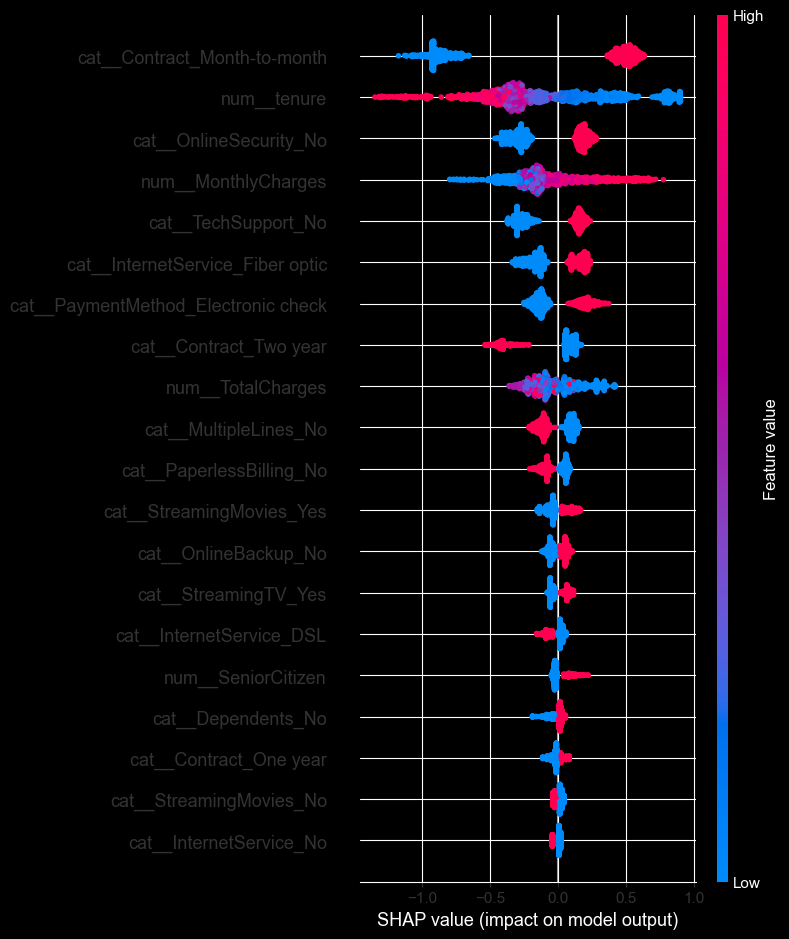

In [14]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=best_model.named_steps["prep"].get_feature_names_out()
)

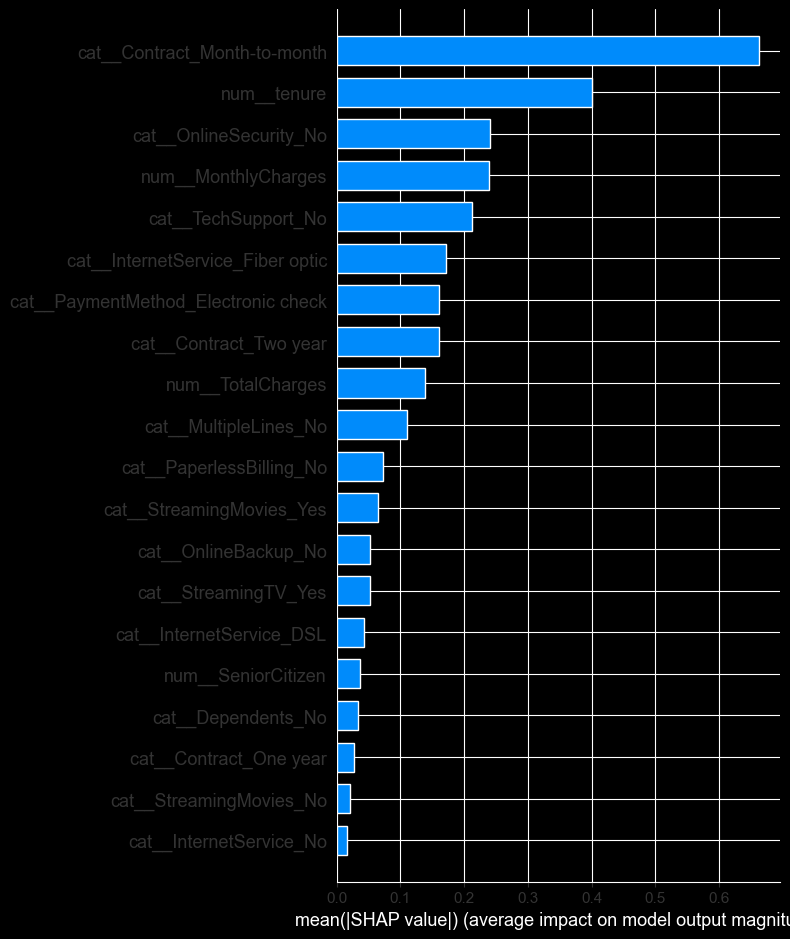

In [15]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=best_model.named_steps["prep"].get_feature_names_out(),
    plot_type="bar"
)

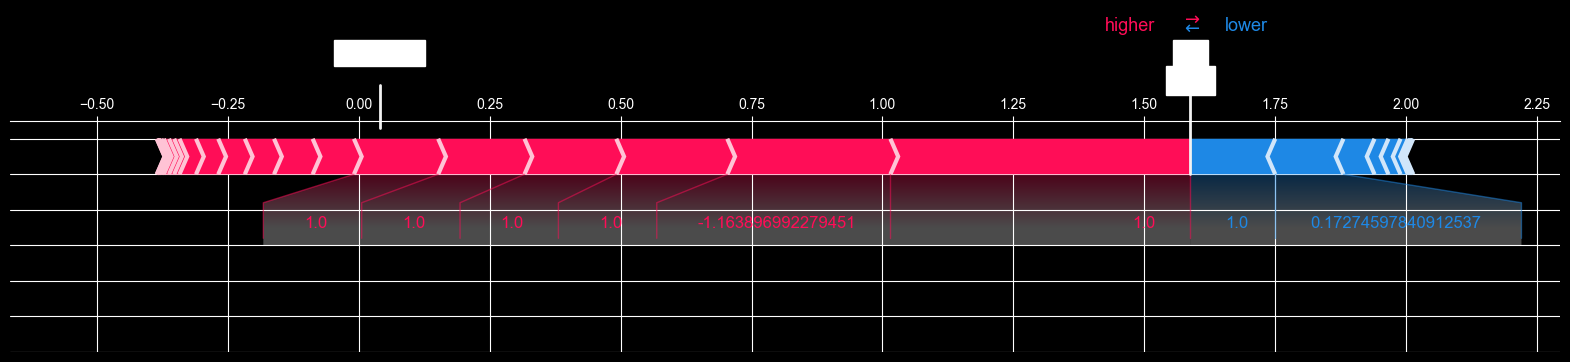

In [16]:
idx = 10  # any test sample index
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_transformed[idx],
    matplotlib=True
)

In [17]:
import matplotlib.pyplot as plt
import shap
from pathlib import Path

outdir = Path(r"C:\Users\Sana\PycharmProjects\telco-churn-xgb\reports\figures")
outdir.mkdir(parents=True, exist_ok=True)

# 1) Beeswarm
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=best_model.named_steps["prep"].get_feature_names_out(),
    show=False
)
plt.tight_layout()
plt.savefig(outdir / "shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.close()

# 2) Global bar plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=best_model.named_steps["prep"].get_feature_names_out(),
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig(outdir / "shap_bar.png", dpi=300, bbox_inches="tight")
plt.close()

# (Optional) single-customer force plot rendered as matplotlib figure
idx = 10
plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_transformed[idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig(outdir / f"shap_force_idx{idx}.png", dpi=300, bbox_inches="tight")
plt.close()

<Figure size 640x480 with 0 Axes>

In [19]:
from sklearn.metrics import classification_report, precision_recall_curve
import numpy as np

proba_test = best_model.predict_proba(X_test)[:, 1]

# Contact capacity: top 20% by risk
cut = np.quantile(proba_test, 0.80)
y_flag20 = (proba_test >= cut).astype(int)
print(classification_report(y_test, y_flag20, digits=3))

              precision    recall  f1-score   support

           0      0.831     0.904     0.866      1033
           1      0.650     0.492     0.560       374

    accuracy                          0.795      1407
   macro avg      0.741     0.698     0.713      1407
weighted avg      0.783     0.795     0.785      1407



In [20]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

# predictions (after tuning)
y_pred = (proba_test >= 0.5).astype(int)   # threshold = 0.5

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))

# Detailed Report
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.727
              precision    recall  f1-score   support

           0      0.911     0.696     0.789      1033
           1      0.492     0.813     0.613       374

    accuracy                          0.727      1407
   macro avg      0.702     0.754     0.701      1407
weighted avg      0.800     0.727     0.742      1407



<Figure size 600x500 with 0 Axes>

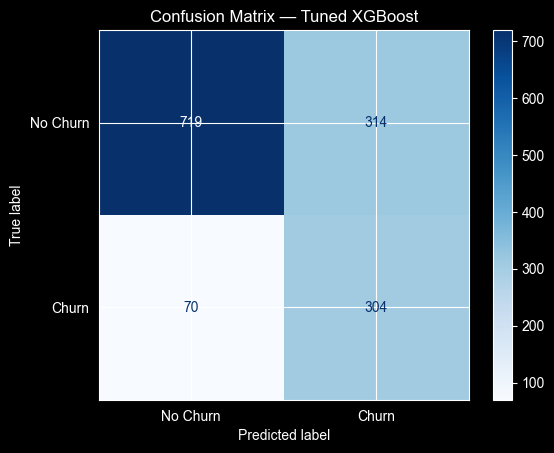

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix — Tuned XGBoost")
plt.show()

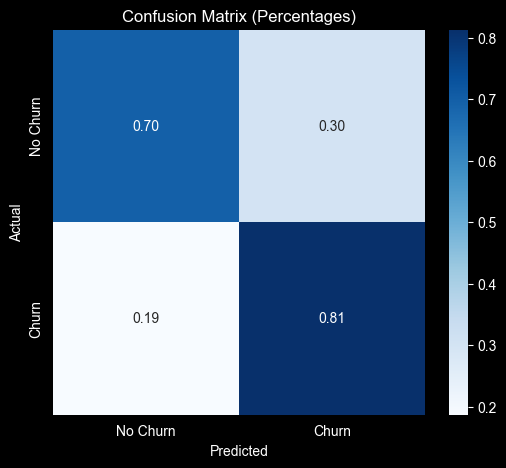

In [22]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(6,5))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, None]

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix (Percentages)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
import joblib
import pathlib

models_dir = pathlib.Path(r"C:\Users\Sana\PycharmProjects\telco-churn-xgb\models")
models_dir.mkdir(exist_ok=True)

joblib.dump(best_model, models_dir / "xgb_churn_model.pkl")

print("Model saved at models/xgb_churn_model.pkl")

Model saved at models/xgb_churn_model.pkl


In [24]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path(r"C:\Users\Sana\PycharmProjects\telco-churn-xgb\reports\figures")

fig, ax = plt.subplots(figsize=(7,6))
RocCurveDisplay.from_predictions(y_test, proba_test, ax=ax)
plt.title("ROC Curve — Tuned XGBoost")
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve.png", dpi=300)
plt.close()

print("ROC curve saved as reports/figures/roc_curve.png")

ROC curve saved as reports/figures/roc_curve.png


In [25]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb_final = best_model.named_steps["clf"]

fig, ax = plt.subplots(figsize=(8,6))
xgb.plot_importance(xgb_final, ax=ax, max_num_features=20)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig(figures_dir / "xgb_feature_importance.png", dpi=300)
plt.close()

print("Feature importance saved as reports/figures/xgb_feature_importance.png")

Feature importance saved as reports/figures/xgb_feature_importance.png
